In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('../data/ceo_salary_1990.csv')
print(df.head())
print(df.info())
print(df.describe())

   salary  pcsalary    sales   roe  pcroe  ros  indus  finance  consprod  \
0    1095        20  27595.0  14.1  106.4  191      1        0         0   
1    1001        32   9958.0  10.9  -30.6   13      1        0         0   
2    1122         9   6125.9  23.5  -16.3   14      1        0         0   
3     578        -9  16246.0   5.9  -25.7  -21      1        0         0   
4    1368         7  21783.2  13.8   -3.0   56      1        0         0   

   utility   lsalary     lsales  
0        0  6.998509  10.225390  
1        0  6.908755   9.206132  
2        0  7.022868   8.720281  
3        0  6.359574   9.695602  
4        0  7.221105   9.988894  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   salary    209 non-null    int64  
 1   pcsalary  209 non-null    int64  
 2   sales     209 non-null    float64
 3   roe       209 non-null    float64


Best Alpha from 5-Fold CV: 0.054303
Nodes in CV-Optimal Tree: 1
Final Test MSE with CV-Pruned Tree: 0.3383
Final Test RMSE with CV-Pruned Tree: 0.5817


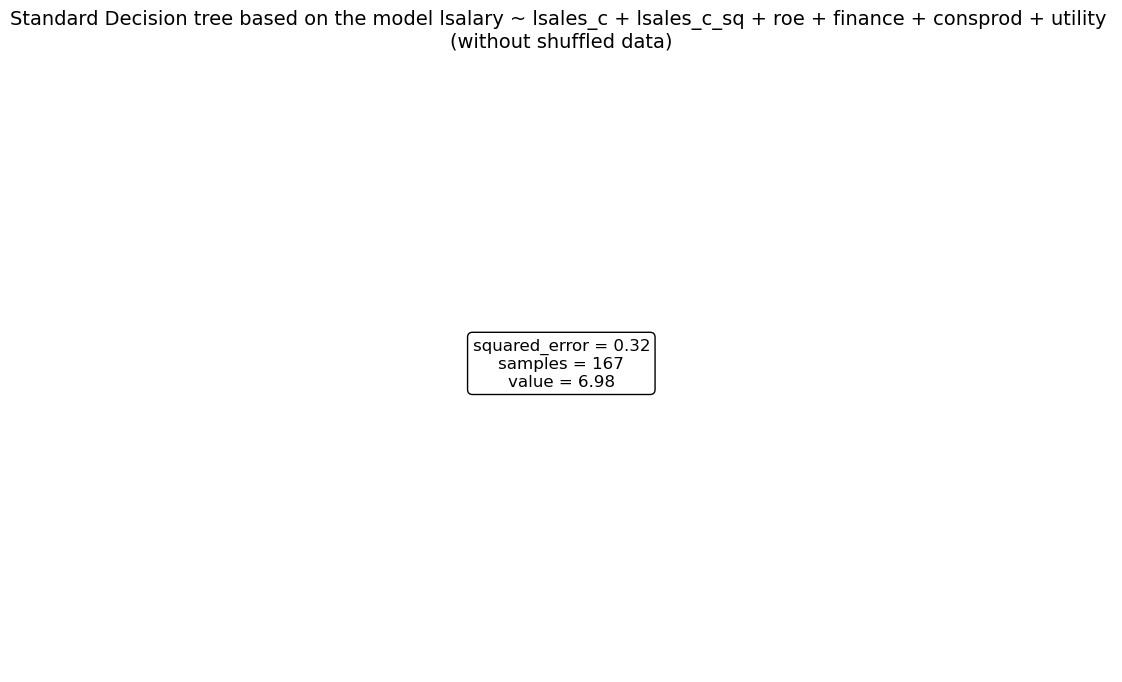

In [2]:
df['lsales_c'] = df['lsales'] - df['lsales'].mean()
df['lsales_c_sq'] = df['lsales_c']**2
# Standard Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility without shuffled data
X = df[['lsales_c', 'lsales_c_sq', 'roe', 'finance', 'consprod', 'utility']]
y = df['lsalary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,                
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_

best_alpha_cv = grid_search.best_params_['ccp_alpha']
print(f"Best Alpha from 5-Fold CV: {best_alpha_cv:.6f}")
print(f"Nodes in CV-Optimal Tree: {best_tree.tree_.node_count}")


y_pred = best_tree.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final Test MSE with CV-Pruned Tree: {final_mse:.4f}")
print(f"Final Test RMSE with CV-Pruned Tree: {final_rmse:.4f}")

plt.figure(figsize=(12, 8), dpi=100)
plot_tree(best_tree, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2)

plt.title(f"Standard Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility \n(without shuffled data)", fontsize=14)
plt.show()

Best Alpha from 5-Fold CV: 0.021933
Nodes in CV-Optimal Tree: 7
Final Test MSE with CV-Pruned Tree: 0.3268
Final Test RMSE with CV-Pruned Tree: 0.5716


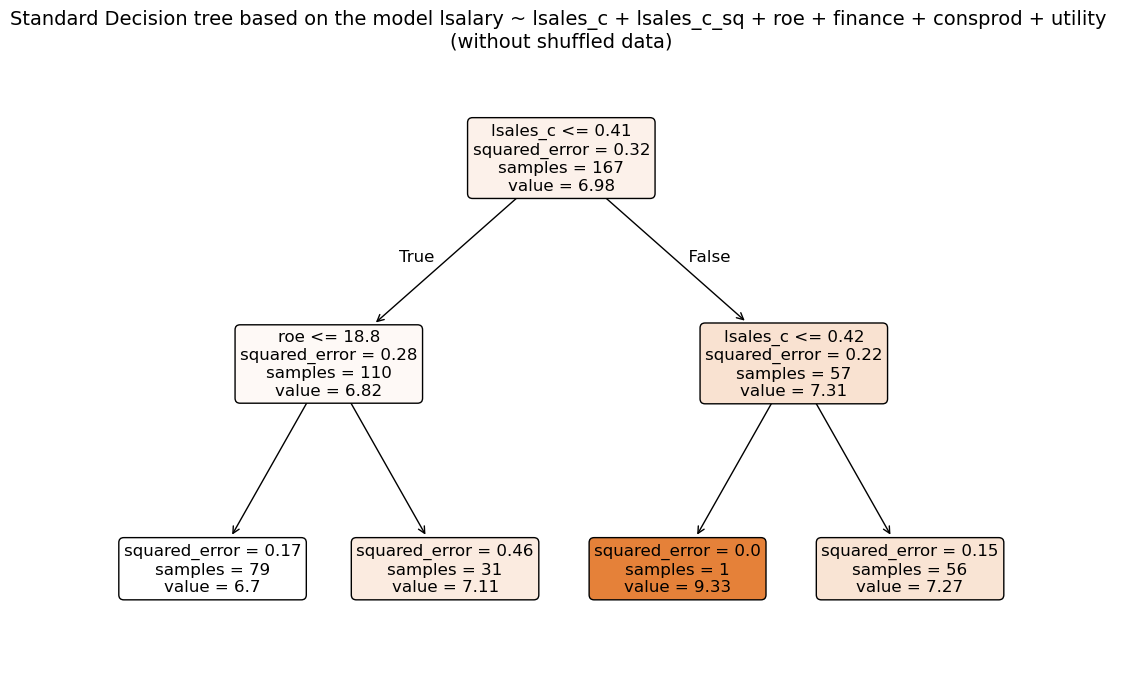

In [3]:
#Standard Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility without shuffled data
X = df[['lsales_c', 'lsales_c_sq', 'roe', 'finance', 'consprod', 'utility']]
y = df['lsalary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities


param_grid = {'ccp_alpha': ccp_alphas[:-1]} #We introduce ccp_alphas[:-1] to force the algorithm to make a split
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,                
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_

best_alpha_cv = grid_search.best_params_['ccp_alpha']
print(f"Best Alpha from 5-Fold CV: {best_alpha_cv:.6f}")
print(f"Nodes in CV-Optimal Tree: {best_tree.tree_.node_count}")


y_pred = best_tree.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final Test MSE with CV-Pruned Tree: {final_mse:.4f}")
print(f"Final Test RMSE with CV-Pruned Tree: {final_rmse:.4f}")

plt.figure(figsize=(12, 8), dpi=100)
plot_tree(best_tree, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2)

plt.title(f"Standard Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility \n(without shuffled data)", fontsize=14)
plt.show()

Best Alpha from 5-Fold CV: 0.016327
Nodes in CV-Optimal Tree: 9
Final Test MSE with CV-Pruned Tree: 0.2127
Final Test RMSE with CV-Pruned Tree: 0.4612


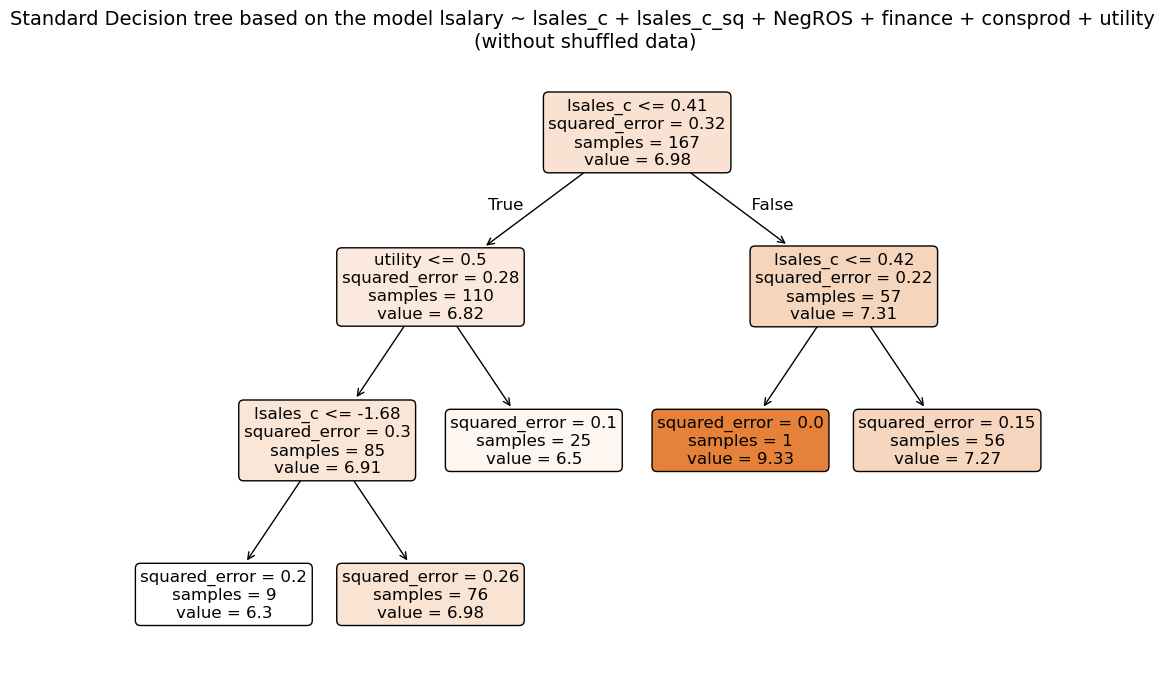

In [4]:
#Standard Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility without shuffled data
df['NegROS'] = (df['ros'] < 0).astype(int)
X = df[['lsales_c', 'lsales_c_sq', 'NegROS', 'finance', 'consprod', 'utility']]
y = df['lsalary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,                
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_

best_alpha_cv = grid_search.best_params_['ccp_alpha']
print(f"Best Alpha from 5-Fold CV: {best_alpha_cv:.6f}")
print(f"Nodes in CV-Optimal Tree: {best_tree.tree_.node_count}")


y_pred = best_tree.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final Test MSE with CV-Pruned Tree: {final_mse:.4f}")
print(f"Final Test RMSE with CV-Pruned Tree: {final_rmse:.4f}")

plt.figure(figsize=(12, 8), dpi=100)
plot_tree(best_tree, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2)

plt.title(f"Standard Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility \n(without shuffled data)", fontsize=14)
plt.show()

Best Alpha from 5-Fold CV: 0.054303
Nodes in CV-Optimal Tree: 1
Final Test MSE with CV-Pruned Tree: 0.3383
Final Test RMSE with CV-Pruned Tree: 0.5817


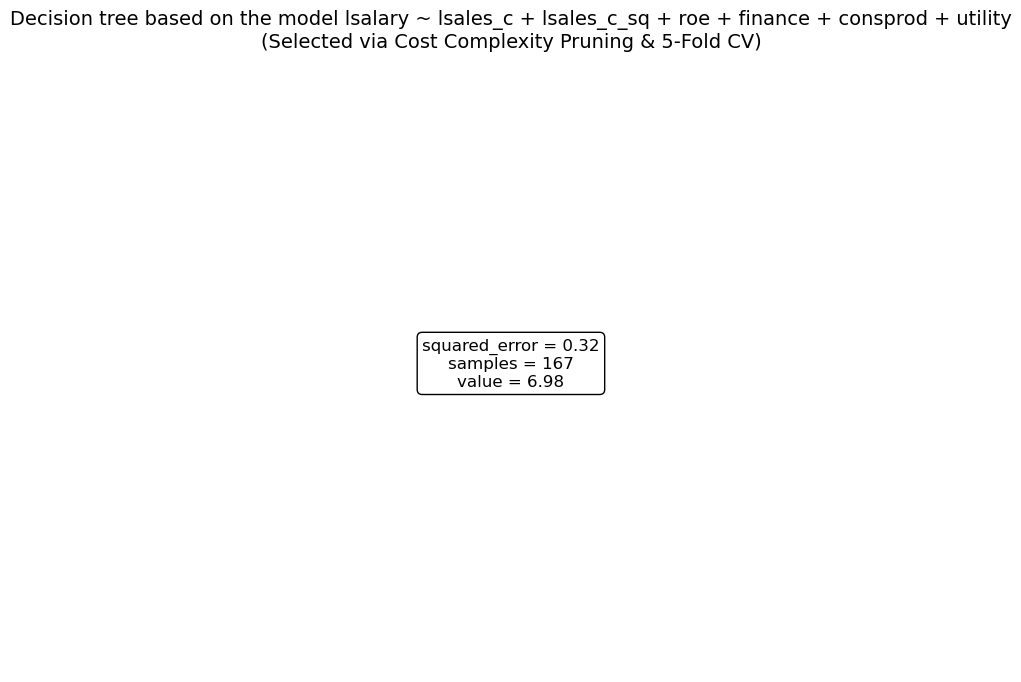

In [5]:
#Refined Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility with shuffled data
X = df[['lsales_c', 'lsales_c_sq', 'roe', 'finance', 'consprod', 'utility']]
y = df['lsalary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities


param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42), #we introduce min_samples_leaf=5
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),                
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_


best_alpha_cv = grid_search.best_params_['ccp_alpha']
print(f"Best Alpha from 5-Fold CV: {best_alpha_cv:.6f}")
print(f"Nodes in CV-Optimal Tree: {best_tree.tree_.node_count}")

y_pred = best_tree.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final Test MSE with CV-Pruned Tree: {final_mse:.4f}")
print(f"Final Test RMSE with CV-Pruned Tree: {final_rmse:.4f}")

plt.figure(figsize=(12, 8), dpi=100)
plot_tree(best_tree, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2)

plt.title(f"Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility\n(Selected via Cost Complexity Pruning & 5-Fold CV)", fontsize=14)
plt.show()

Best Alpha from 5-Fold CV: 0.008663
Nodes in CV-Optimal Tree: 11
Final Test MSE with CV-Pruned Tree: 0.2767
Final Test RMSE with CV-Pruned Tree: 0.5260


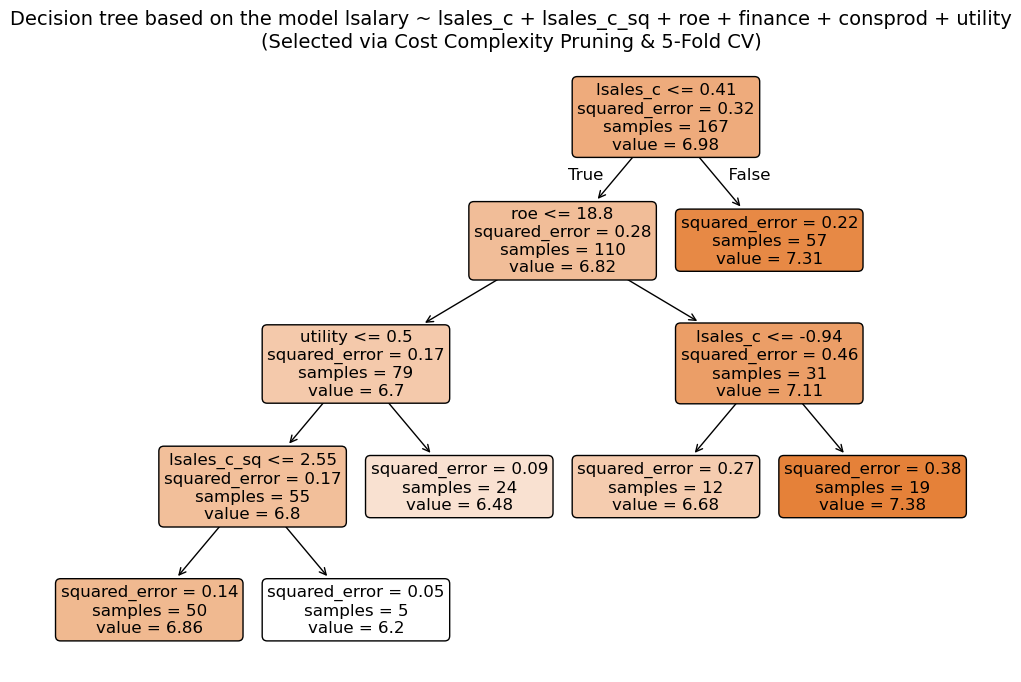

In [6]:
#Refined Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility with shuffled data
X = df[['lsales_c', 'lsales_c_sq', 'roe', 'finance', 'consprod', 'utility']]
y = df['lsalary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities


param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42, min_samples_leaf=5), #we introduce min_samples_leaf=5
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),                
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_


best_alpha_cv = grid_search.best_params_['ccp_alpha']
print(f"Best Alpha from 5-Fold CV: {best_alpha_cv:.6f}")
print(f"Nodes in CV-Optimal Tree: {best_tree.tree_.node_count}")

y_pred = best_tree.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final Test MSE with CV-Pruned Tree: {final_mse:.4f}")
print(f"Final Test RMSE with CV-Pruned Tree: {final_rmse:.4f}")

plt.figure(figsize=(12, 8), dpi=100)
plot_tree(best_tree, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2)

plt.title(f"Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility\n(Selected via Cost Complexity Pruning & 5-Fold CV)", fontsize=14)
plt.show()

Best Alpha from 5-Fold CV: 0.016327
Nodes in CV-Optimal Tree: 9
Final Test MSE with CV-Pruned Tree: 0.2127
Final Test RMSE with CV-Pruned Tree: 0.4612


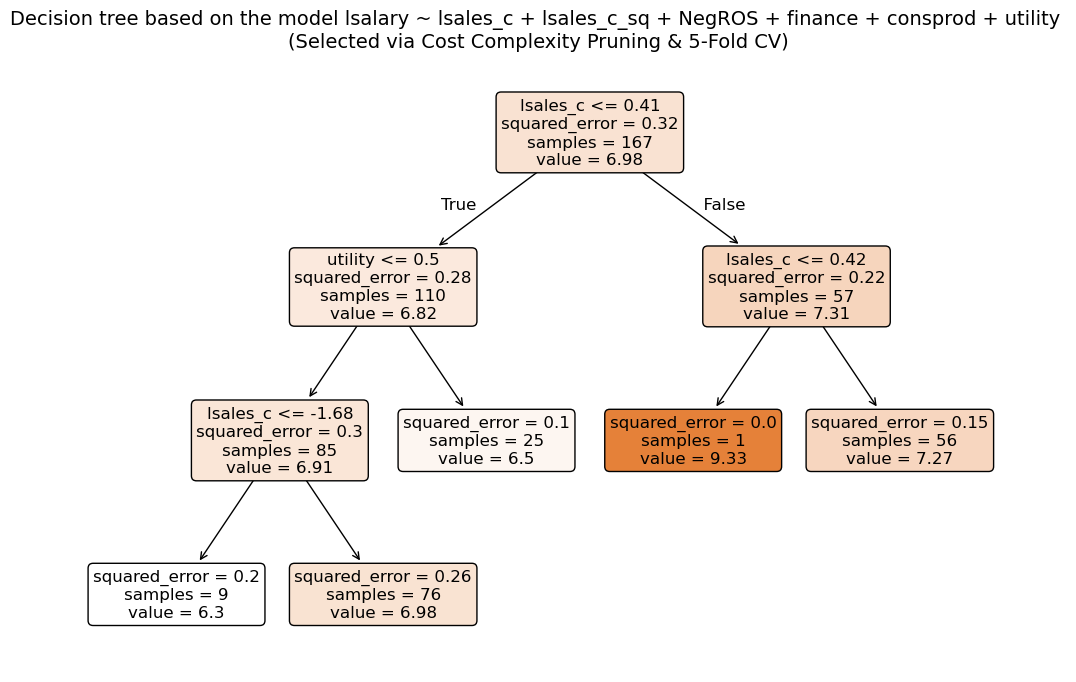

In [7]:
#Refined Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility with shuffled data
X = df[['lsales_c', 'lsales_c_sq', 'NegROS', 'finance', 'consprod', 'utility']]
y = df['lsalary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities


param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42), 
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),                
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_


best_alpha_cv = grid_search.best_params_['ccp_alpha']
print(f"Best Alpha from 5-Fold CV: {best_alpha_cv:.6f}")
print(f"Nodes in CV-Optimal Tree: {best_tree.tree_.node_count}")

y_pred = best_tree.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final Test MSE with CV-Pruned Tree: {final_mse:.4f}")
print(f"Final Test RMSE with CV-Pruned Tree: {final_rmse:.4f}")

plt.figure(figsize=(12, 8), dpi=100)
plot_tree(best_tree, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2)

plt.title(f"Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility \n(Selected via Cost Complexity Pruning & 5-Fold CV)", fontsize=14)
plt.show()

Best Alpha from 5-Fold CV: 0.006050
Nodes in CV-Optimal Tree: 13
Final Test MSE with CV-Pruned Tree: 0.1924
Final Test RMSE with CV-Pruned Tree: 0.4387


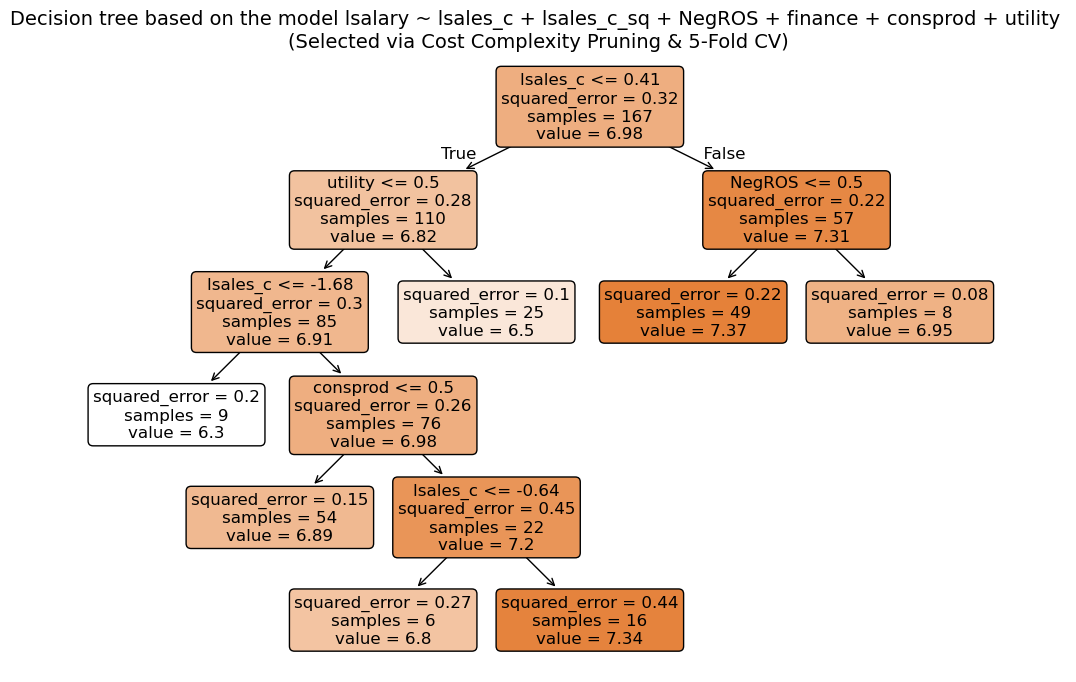

In [8]:
#Refined Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility with shuffled data
X = df[['lsales_c', 'lsales_c_sq', 'NegROS', 'finance', 'consprod', 'utility']]
y = df['lsalary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities


param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42, min_samples_leaf=5), #we introduce min_samples_leaf=5
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),                
    scoring='neg_mean_squared_error'
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_


best_alpha_cv = grid_search.best_params_['ccp_alpha']
print(f"Best Alpha from 5-Fold CV: {best_alpha_cv:.6f}")
print(f"Nodes in CV-Optimal Tree: {best_tree.tree_.node_count}")

y_pred = best_tree.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Final Test MSE with CV-Pruned Tree: {final_mse:.4f}")
print(f"Final Test RMSE with CV-Pruned Tree: {final_rmse:.4f}")

plt.figure(figsize=(12, 8), dpi=100)
plot_tree(best_tree, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2)

plt.title(f"Decision tree based on the model lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility \n(Selected via Cost Complexity Pruning & 5-Fold CV)", fontsize=14)
plt.show()

In [15]:
from sklearn.model_selection import KFold, train_test_split

features = ['lsales_c', 'lsales_c_sq', 'roe', 'NegROS', 'finance', 'consprod', 'utility']
X = df[features]
y = df['lsalary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#random forest based on the model lsalary ~ lsales_c + lsales_c_sq + roe + finance + consprod + utility
features1 = ['lsales_c', 'lsales_c_sq', 'roe', 'finance', 'consprod', 'utility']
X_train1 = X_train[features1]
X_test1 = X_test[features1]

rf_model1 = RandomForestRegressor(n_estimators=500, max_features='sqrt', random_state=42)
rf_model1.fit(X_train1, y_train)

y_pred1 = rf_model1.predict(X_test1) 

rf_mse = mean_squared_error(y_test, y_pred1)
rf_rmse = np.sqrt(rf_mse)
r2 = r2_score(y_test, y_pred1)

single_data = X_test1.iloc[[0]] 
predicted_value = rf_model1.predict(single_data)

print(f"Random Forest (Model 1) Test MSE: {rf_mse:.4f}")
print(f"Random Forest (Model 1) R^2: {r2:.4f}")
print(f"Predicted Value: {predicted_value[0]:.2f}")
print(f"Actual Value: {y_test.iloc[0]:.2f}")

importances1 = rf_model1.feature_importances_
for i, feat in enumerate(features1):
    print(f"Importance of {feat}: {importances1[i]:.4f}")

Random Forest (Model 1) Test MSE: 0.2693
Random Forest (Model 1) R^2: 0.1343
Predicted Value: 7.29
Actual Value: 6.93
Importance of lsales_c: 0.3787
Importance of lsales_c_sq: 0.2338
Importance of roe: 0.2557
Importance of finance: 0.0215
Importance of consprod: 0.0485
Importance of utility: 0.0617


In [17]:
#random forest based on the model lsalary ~ lsales_c + lsales_c_sq + NegROS + finance + consprod + utility
features2 = ['lsales_c', 'lsales_c_sq', 'NegROS', 'finance', 'consprod', 'utility']
X_train2 = X_train[features2]
X_test2 = X_test[features2]

rf_model2 = RandomForestRegressor(n_estimators=500, max_features='sqrt', random_state=42)
rf_model2.fit(X_train2, y_train)

y_pred2 = rf_model2.predict(X_test2)

rf_mse2 = mean_squared_error(y_test, y_pred2)
rf_rmse2 = np.sqrt(rf_mse2)
r2_2 = r2_score(y_test, y_pred2)

single_data2 = X_test2.iloc[[0]]
predicted_value2 = rf_model2.predict(single_data2)

print(f"Random Forest (Model 2 - NegROS) Test MSE: {rf_mse2:.4f}")
print(f"Random Forest (Model 2 - NegROS) Test RMSE: {rf_rmse2:.4f}")
print(f"Random Forest (Model 2 - NegROS) R^2: {r2_2:.4f}")
print(f"Predicted Value: {predicted_value2[0]:.2f}")
print(f"Actual Value: {y_test.iloc[0]:.2f}")

importances2 = rf_model2.feature_importances_
print("\nFeature Importances for Model 2:")
for i, feat in enumerate(features2):
    print(f"Importance of {feat}: {importances2[i]:.4f}")

Random Forest (Model 2 - NegROS) Test MSE: 0.2821
Random Forest (Model 2 - NegROS) Test RMSE: 0.5311
Random Forest (Model 2 - NegROS) R^2: 0.0933
Predicted Value: 7.19
Actual Value: 6.93

Feature Importances for Model 2:
Importance of lsales_c: 0.4858
Importance of lsales_c_sq: 0.3342
Importance of NegROS: 0.0265
Importance of finance: 0.0187
Importance of consprod: 0.0582
Importance of utility: 0.0766
